## ERCOT - RTM vs. Load correlation
Data sources:
- **rtm price:** `data/02_processed/RTM price cleaned/rtm_price_aggregated_2021_2025.csv`
- **load:** `data/02_processed/load/load LZ/total_load_20201231_20260526.csv`

Output:
- rtm vs. load correlation (faceted by year)
**output:** `price adder correlation`

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
PROJECT_ROOT = Path('../..').resolve()
RTM_PRICE = PROJECT_ROOT / '01_data/2_cleaned/rtm_price/rtm_price_aggregated_2021_2025.csv'
LOAD = PROJECT_ROOT / '01_data/2_cleaned/load/total_load_20201231_20260526.csv'

OUT_DIR = PROJECT_ROOT / '01_data/3_analysis/output'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df_rtm = pd.read_csv(RTM_PRICE)
df_rtm.head()

,date_time,avg_rtm_price,std_rtm_price
0,2021-01-01 01:00:00,18.714000,1.508854
1,2021-01-01 02:00:00,18.107333,1.512517
2,2021-01-01 03:00:00,17.570000,1.537424
3,2021-01-01 04:00:00,17.670667,1.540869
4,2021-01-01 05:00:00,17.792000,1.997417


In [4]:
df_load = pd.read_csv(LOAD)
df_load.head()

,datetime,total_load
0,2020-12-31 01:00:00,39174.39
1,2020-12-31 02:00:00,38284.84
2,2020-12-31 03:00:00,37776.69
3,2020-12-31 04:00:00,37781.84
4,2020-12-31 05:00:00,38455.69


In [5]:
df_load['datetime'] = pd.to_datetime(df_load['datetime'])
df_rtm['date_time'] = pd.to_datetime(df_rtm['date_time'])
df_merge = df_load.merge(df_rtm, left_on='datetime', right_on='date_time')
df_merge = df_merge[['datetime', 'total_load', 'avg_rtm_price']]
df_merge.head()

,datetime,total_load,avg_rtm_price
0,2021-01-01 01:00:00,43713.80,18.714000
1,2021-01-01 02:00:00,43314.37,18.107333
2,2021-01-01 03:00:00,43048.35,17.570000
3,2021-01-01 04:00:00,43073.65,17.670667
4,2021-01-01 05:00:00,43448.89,17.792000


Text(0.5, 1.0, 'ERCOT Load vs. Power Price')

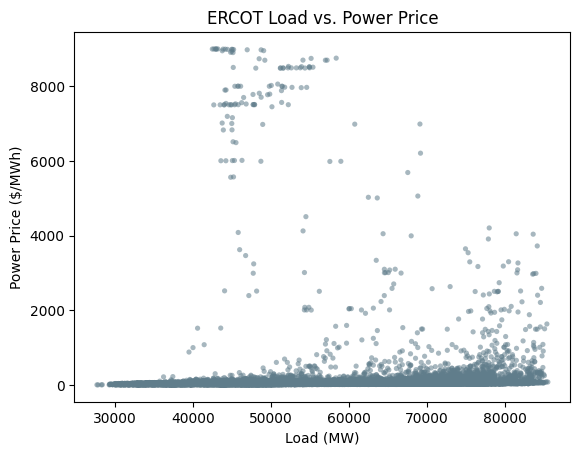

In [6]:
df_plot = df_merge.copy()
df_plot = df_plot.set_index('datetime')
x = df_plot["total_load"]
y = df_plot["avg_rtm_price"]

plt.scatter(x, y, s=14, alpha=0.55, color="#607D8B", edgecolors="none")
xline = np.linspace(x.min(), x.max(), 200)

#plt.plot(xline, xline, color="#000000", lw=1.2, ls="--", label="1:1 Line")

plt.xlabel("Load (MW)")
plt.ylabel("Power Price ($/MWh)")
plt.title('ERCOT Load vs. Power Price')

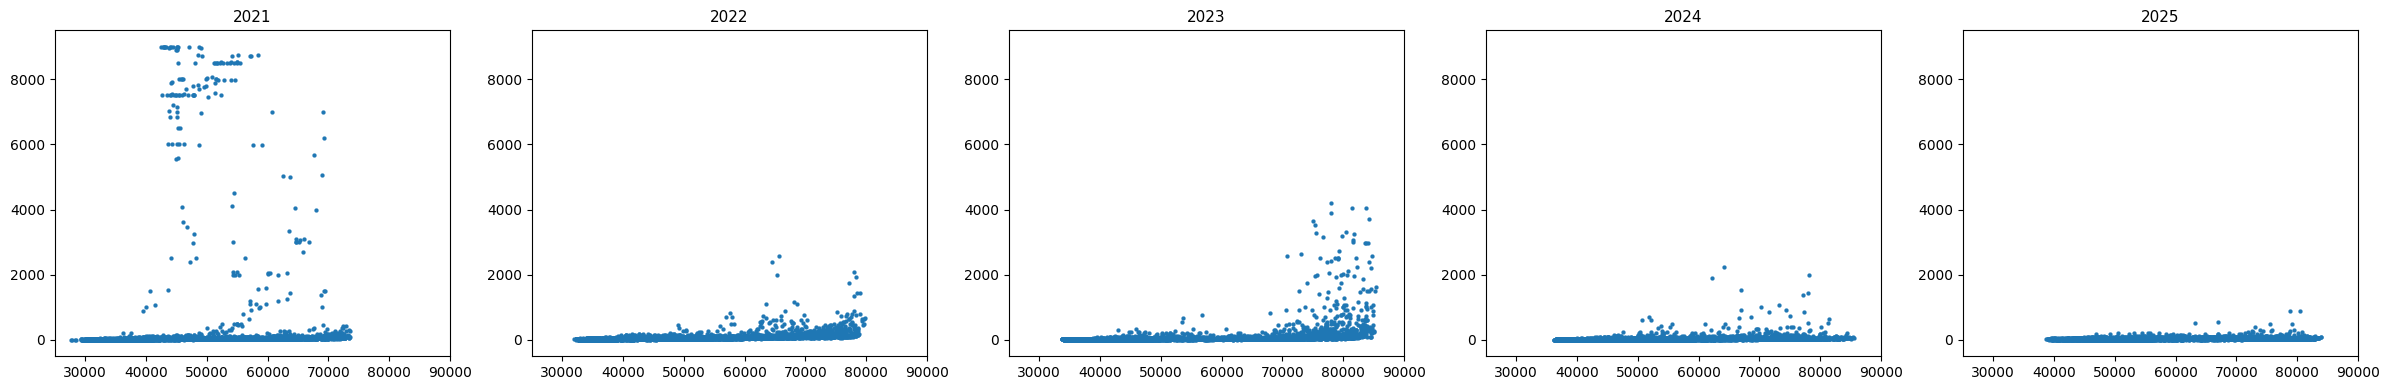

In [12]:
df_plot['year'] = df_plot.index.year
years = [2021, 2022, 2023, 2024, 2025]

fig, axes = plt.subplots(1, 5, figsize=(24, 4), sharex=True)
axes = axes.flatten()

for ax, year in zip(axes, years):
    year_data = df_plot[df_plot['year'] == year]
    ax.scatter(year_data['total_load'], year_data['avg_rtm_price'], lw=0.2, s=8)
    ax.set_title(year, fontsize=11)
    ax.set_ylim(-500, 9500)
    ax.set_xlim(25000, 90000)

plt.tight_layout()
plt.show()

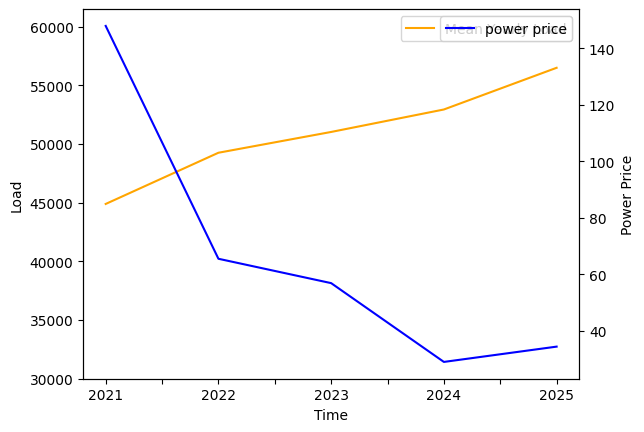

In [87]:
# load trend
df_plot2 = df_plot.reset_index()
df_plot2['year'] = df_plot2['datetime'].dt.strftime("%Y")
df_trend = df_plot2.groupby('year').mean().reset_index()

ax = df_trend.plot(x='year', y='total_load', color='orange', label='Mean Yearly Load')
plt.ylim(30000, df_trend['total_load'].max()+5000)
ax2 = ax.twinx()
ax2.plot(df_trend['year'], df_trend['avg_rtm_price'], color='blue', label='power price')
ax.set_xlabel('Time')
ax.set_ylabel('Load')
ax2.set_ylabel('Power Price')
ax.legend()
ax2.legend()